Dataset Shape: (330, 15)

Unique Methods: ['OHE' 'Bigram' 'W2V' 'D2V' 'BERT' 'ACF']
Unique Strategies: ['prefix' 'last_k']

--- Average Performance by Method ---
        accuracy  f1_score
method                    
W2V     0.722150  0.695966
BERT    0.690042  0.675158
OHE     0.624799  0.583854
Bigram  0.543825  0.493084
ACF     0.514762  0.480150
D2V     0.404144  0.344442

--- Mean Accuracy (Strategy vs Method) ---
method         ACF      BERT    Bigram       D2V       OHE       W2V
strategy                                                            
last_k    0.566987  0.706569  0.592074  0.419465  0.684503  0.720054
prefix    0.305863  0.623934  0.350828  0.342860  0.385981  0.730533


C:\Users\Gijs Koppenberg\AppData\Local\Temp\ipykernel_4292\1658555236.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='method', y='accuracy', palette='viridis')


Text(0.5, 1.0, 'Accuracy vs Grid Search Time')

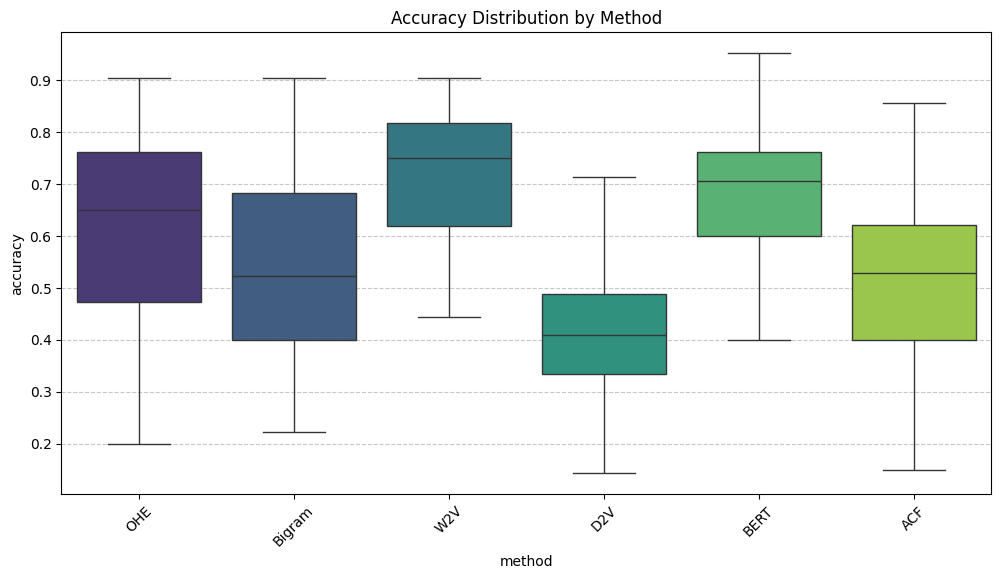

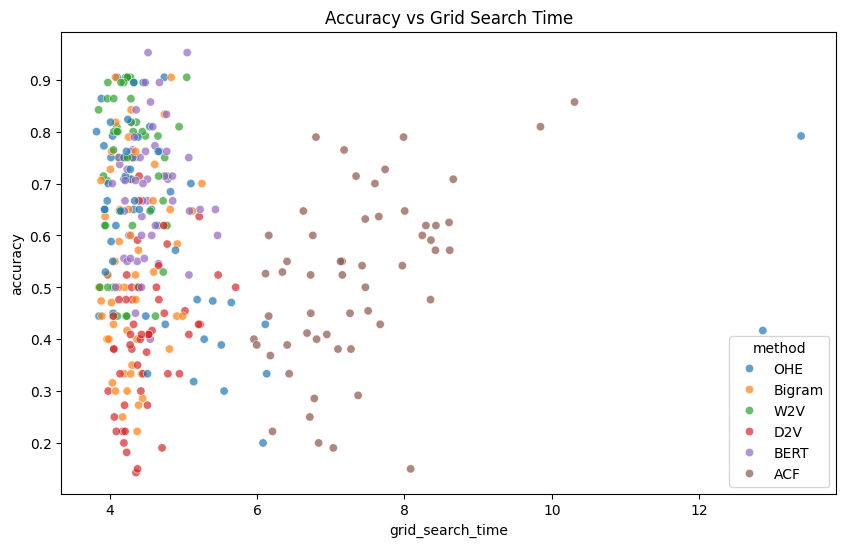

In [13]:
# Loading csv and imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('results/experiment_results_2017.csv')

# 2. Data Cleaning: Filter for successful experiments only
# Since some experiments might have failed (NaN in accuracy/f1_score)
df_clean = df[df['status'] == 'Success'].copy()

# 3. Basic Exploration
print("Dataset Shape:", df.shape)
print("\nUnique Methods:", df_clean['method'].unique())
print("Unique Strategies:", df_clean['strategy'].unique())

# 4. Performance Summary by Method
# Calculate average accuracy and F1-score for each method
method_summary = df_clean.groupby('method')[['accuracy', 'f1_score']].mean().sort_values(by='accuracy', ascending=False)
print("\n--- Average Performance by Method ---")
print(method_summary)

# 5. Visualization: Accuracy distribution per method
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='method', y='accuracy', palette='viridis')
plt.title('Accuracy Distribution by Method')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)


# 6. Comparative Analysis: Strategy vs Performance
strategy_pivot = df_clean.pivot_table(index='strategy', columns='method', values='accuracy', aggfunc='mean')
print("\n--- Mean Accuracy (Strategy vs Method) ---")
print(strategy_pivot)

# 7. Grid Search Time vs Accuracy
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='grid_search_time', y='accuracy', hue='method', alpha=0.7)
plt.title('Accuracy vs Grid Search Time')


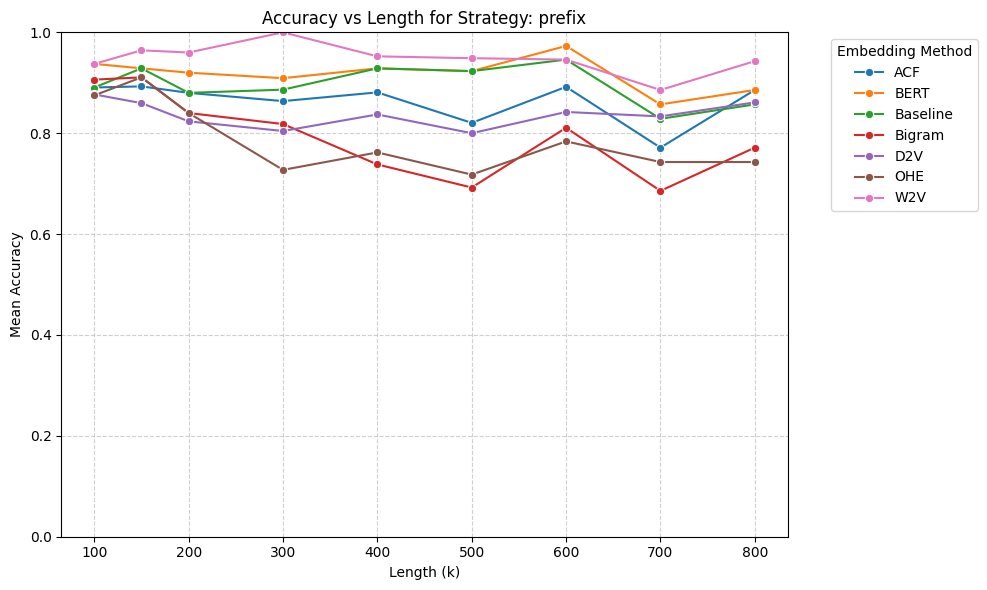

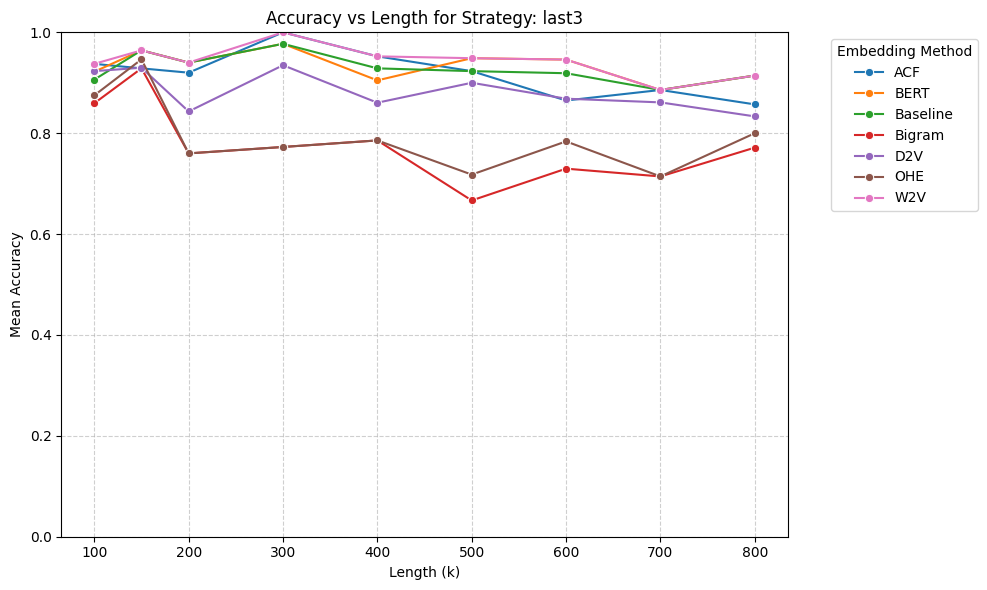

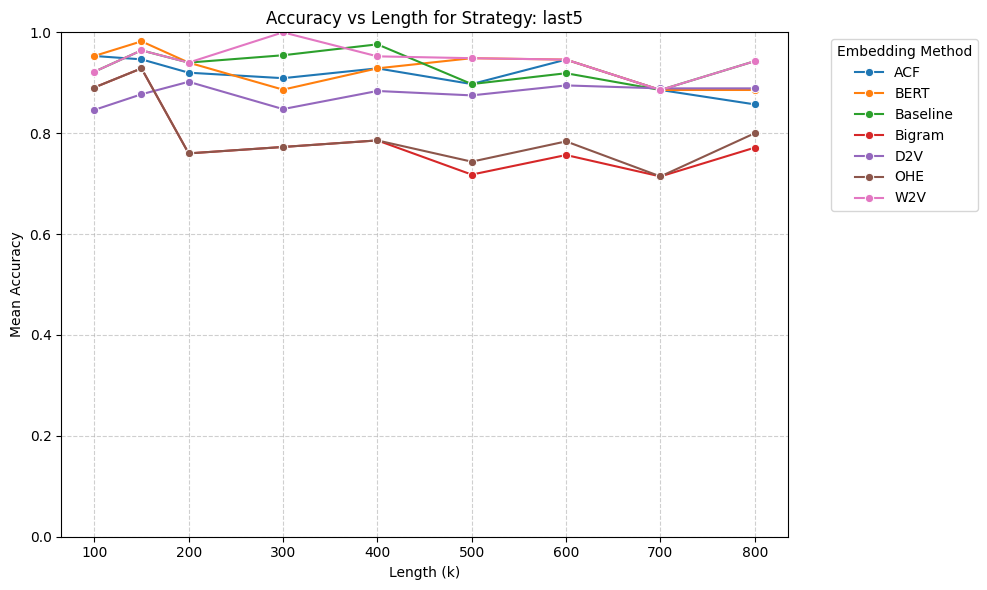

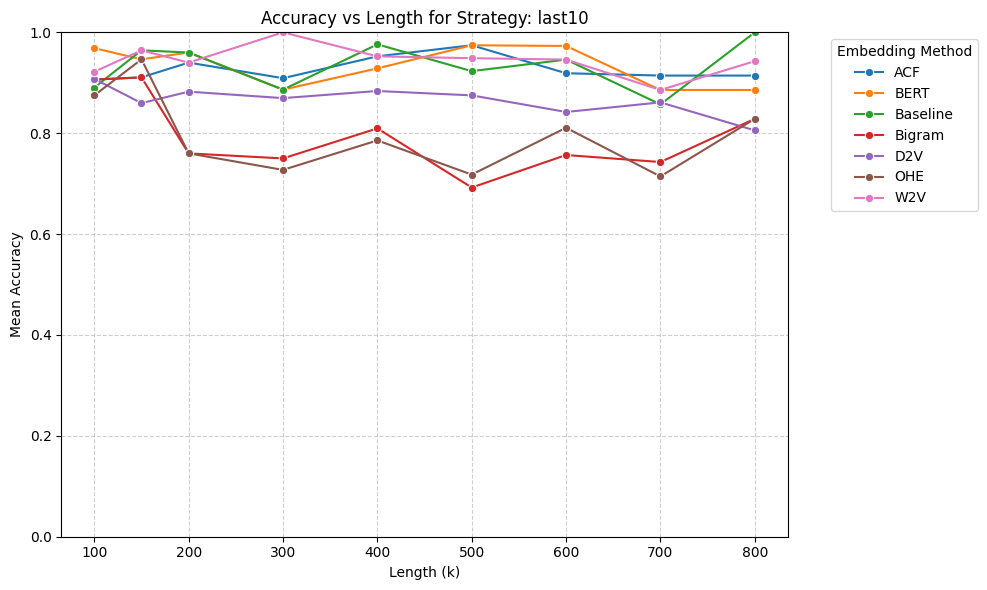

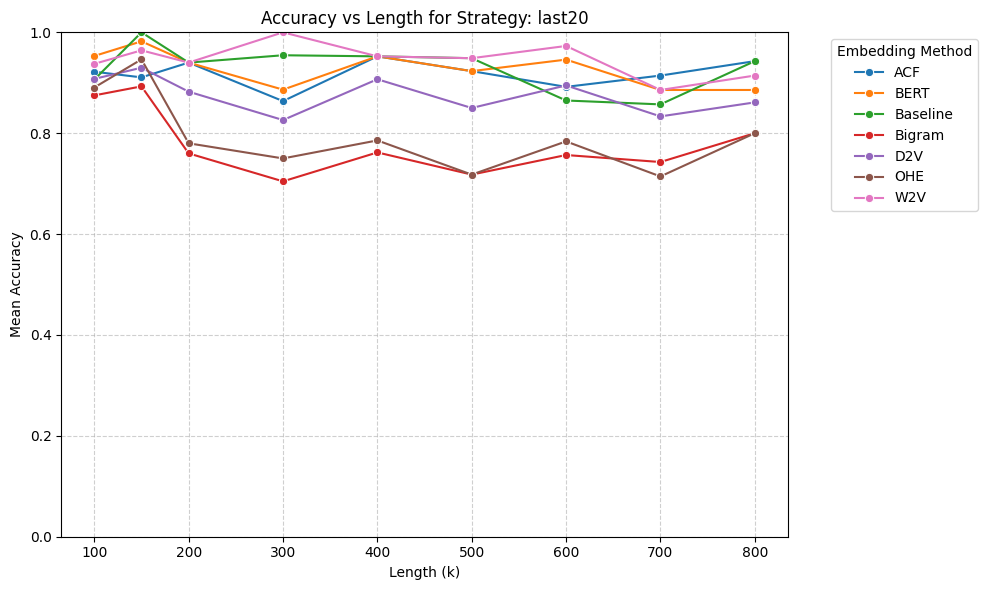

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_csv('results/experiment_results_2019_lgbm.csv', sep=',')
df = df[df['status'] == 'Success']

strategies = ['prefix', 'last3', 'last5', 'last10', 'last20']

for strategy in strategies:
    subset = df[df['strategy'] == strategy]
    
    # Calculate mean accuracy per length and method
    plot_data = subset.groupby(['length_or_k', 'method'])['accuracy'].mean().reset_index()
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=plot_data, x='length_or_k', y='accuracy', hue='method', marker='o')
    plt.title(f'Accuracy vs Length for Strategy: {strategy}')
    plt.xlabel('Length (k)')
    plt.ylim(0.0, 1.0)
    plt.ylabel('Mean Accuracy')
    plt.legend(title='Embedding Method', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"plots/accuracy_plot_{strategy}_2019_lgbm.png")


52
